In [1]:
import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle

import cartopy.crs as ccrs

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


#### Need to show 
* Neural networks beat baselines (more trustworthy than logistic regression or random chance)
* Neural networks predict some consistent emergence time
* Predictions hold in observations

In [135]:
ssplist = ["126","245","370","585"]

ssplistplot = ["hist","126","245","370","585"] # thank god i haven't flipflopped on ssp labeling! that would be so annoying

# set user parameters

experiment_era = [1950,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1960,2025]
baselineera_obs = [1940,1960]

inputlength = 10
outputavgtime = 10

# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
obstimerange = [1940,2025]

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
}

ntrain = 25
nval = 13
test = np.arange(38,50)

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon


data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


In [64]:
_, _, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,-10,0)
_, inputtestGMT, _ = DataHolder.tensortime_onehot(alltest,nclasses=2)

gmt_first_positive = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan
gmt_first_confident = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan
gmt_first_correct = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan

random_chance = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan

cnn_accuracy = np.empty((5,len(AllData.output_lat),len(AllData.output_lon),20))+np.nan

regenerate = False

for ilatsel,latsel in enumerate(AllData.output_lat):

    if (latsel>=0) & (regenerate==False):

        _, _, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,10,0)
        _, inputtestGMT, _ = DataHolder.tensortime_onehot(alltest,nclasses=2)

        regenerate = True
    
    fileopen = "predictions/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_testing.pkl"

    filecheck = glob.glob(fileopen)
    if len(filecheck) != 0:

        with open(filecheck[0],'rb') as f:
            predictions = pickle.load(f)
        
        filetrue = "predictions/"+modelfilefront+"avgtime"+str(outputavgtime)+"_allssps_lat"+str(latsel)+"_truetesting.pkl"
        with open(filetrue,'rb') as f:
            truths = pickle.load(f)

        avgtestpred = np.mean(predictions,axis=1)
        avgtestclass = np.round(avgtestpred)
        avgtestconf = np.where(avgtestpred<0.5,1-avgtestpred,avgtestpred)

        for ilonsel,lonsel in enumerate(AllData.output_lon):

            if np.mean(avgtestpred[ilonsel]) != 0:
        
                for issp,ssp in enumerate(ssplistplot):
                    # if np.mean(avgtestpred[ilonsel]) != 0:

                    inputGMTsel = helpers.grabssp(inputtestGMT.numpy(),issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))
                    predsel = helpers.grabssp(avgtestpred[ilonsel],issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))
                    truesel = helpers.grabssp(truths[ilonsel],issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))

                    predclass = np.round(predsel)
                    predconf = np.where(predsel<0.5,1-predsel,predsel)

                    cnn_accuracy[issp,ilatsel,ilonsel] = helpers.confacc(predclass,truesel,predconf)

                    # first positive prediction
                    gmt_first_positive[issp,ilatsel,ilonsel] = helpers.firstpositive(predsel,inputGMTsel)

                    # first confident, positive prediction
                    gmt_first_confident[issp,ilatsel,ilonsel] = helpers.firstconfident(predsel,inputGMTsel)

                    # first correct, positive prediction 
                    gmt_first_correct[issp,ilatsel,ilonsel] = helpers.firstcorrect(predsel,truesel,inputGMTsel)

                    random_chance[issp,ilatsel,ilonsel] = np.mean(truesel)



baseline for gmt is 60 90
experiment era in the historical is 50 124
baseline for temp records is 0 50
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/DataHolder.py:1470: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


baseline for gmt is 60 90
experiment era in the historical is 50 124
baseline for temp records is 0 50
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585


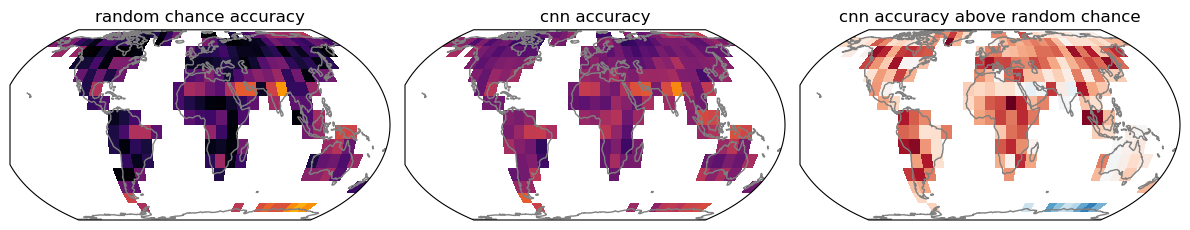

In [61]:
plt.figure(figsize=(12,5))

a1=plt.subplot(1,3,1,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,nulls,vmin=0.5,vmax=0.9,cmap='inferno',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('random chance accuracy')

a1=plt.subplot(1,3,2,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,0],vmin=0.5,vmax=0.9,cmap='inferno',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy')

a1=plt.subplot(1,3,3,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,0]-nulls,vmin=-0.15,vmax=0.15,cmap='RdBu_r',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy above random chance')

plt.tight_layout()

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_45690/915782016.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


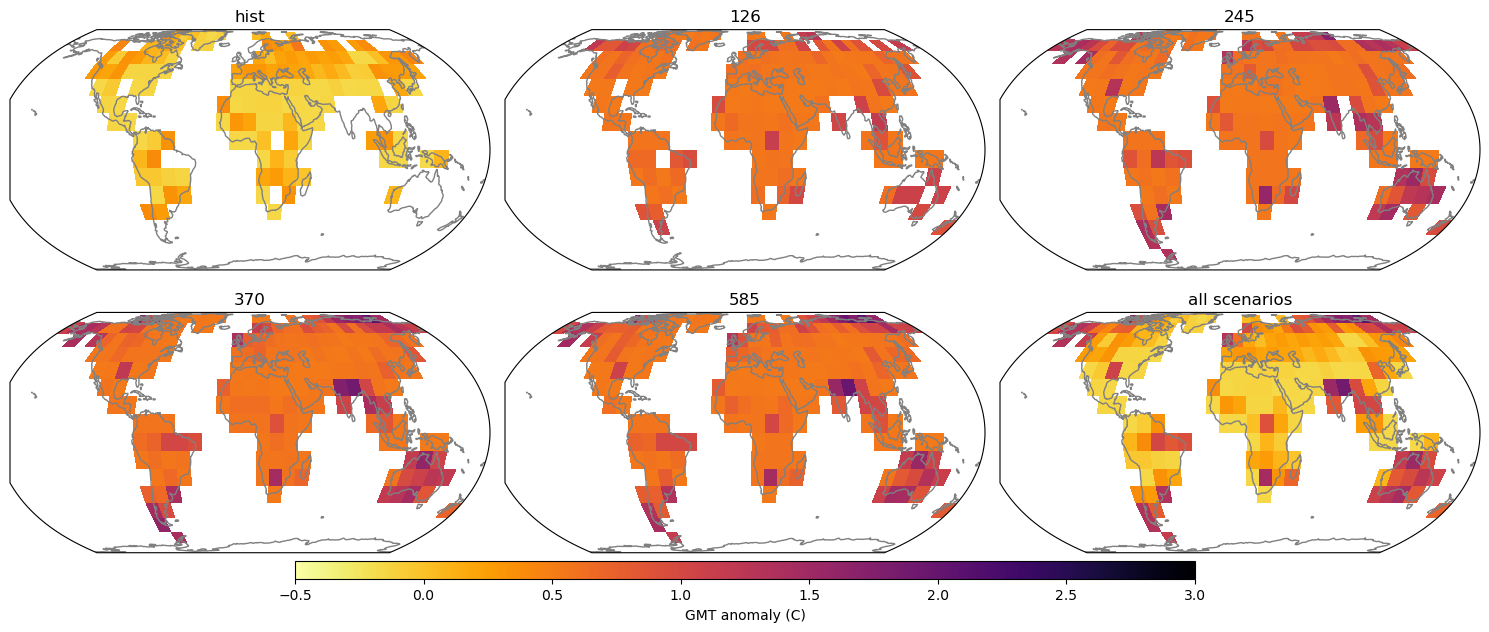

In [ ]:
plt.figure(figsize=(15,6))

for iplot in range(5):

    ax=plt.subplot(2,3,iplot+1,projection=ccrs.EqualEarth())
    c1=ax.pcolormesh(lonvec+5,latvec+5,gmt_first_correct[iplot],vmin=-0.5,vmax=3,cmap='inferno_r',transform=ccrs.PlateCarree())
    plt.title(ssplistplot[iplot])
    ax.coastlines(color='gray')

all_first_correct = np.nanmin(gmt_first_correct,axis=0)

mask = np.isnan(gmt_first_correct[-1])
avgfirstcorrect = np.copy(gmt_first_correct)

avgfirstcorrect[np.isnan(gmt_first_correct)] = 0
avgfirstcorrect[~np.isnan(gmt_first_correct)] = 1
all_first_correct_scenario = np.mean(avgfirstcorrect,axis=0)

all_first_correct_scenario[mask] = np.nan

ax=plt.subplot(2,3,6,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,np.nanmin(gmt_first_correct,axis=0),vmin=-0.5,vmax=3,cmap='inferno_r',transform=ccrs.PlateCarree())
plt.title('all scenarios')
ax.coastlines(color='gray')

cax1 = plt.axes((0.2,0.02,0.6,0.03))
cbar1 = plt.colorbar(c1,cax1,orientation='horizontal')
cbar1.ax.set_xlabel('GMT anomaly 1960-1990 (C)')

# cax2 = plt.axes((0.7,0.02,0.25,0.03))
# cbar2=plt.colorbar(c2,cax2,orientation='horizontal')
# cbar2.ax.set_xlabel('first era of emergence')

plt.tight_layout()
plt.show()


In [67]:
alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,-20,0)

_, inputtrainGMT, _ = DataHolder.tensortime_onehot(alltrain,nclasses=2)
_, inputvalGMT, _ = DataHolder.tensortime_onehot(allval,nclasses=2)
_, inputtestGMT, _ = DataHolder.tensortime_onehot(alltest,nclasses=2)

inputssptrain,inputsspval,inputssptest = AllData.trainvaltest_recordmax_ssps(trainvaltest,experiment_era,inputlength,outputavgtime,-20)

regenerate = False

inputalltrain = np.concatenate((inputtrainGMT.numpy(),inputssptrain),axis=1)
inputallval = np.concatenate((inputvalGMT.numpy(),inputsspval),axis=1)
inputalltest = np.concatenate((inputtestGMT.numpy(),inputssptest),axis=1)

lr_first_positive = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan
lr_first_correct = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan
lr_first_confident = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan

lr_accuracy_ssp = np.empty((5,len(AllData.output_lat),len(AllData.output_lon),20))+np.nan
bs_lr_ssp = np.empty((5,len(AllData.output_lat),len(AllData.output_lon)))+np.nan

lr_accuracy_all = np.empty((len(AllData.output_lat),len(AllData.output_lon),20))+np.nan
bs_lr_all = np.empty((len(AllData.output_lat),len(AllData.output_lon)))+np.nan


for ilatsel,latsel in enumerate(AllData.output_lat):
    print(latsel)

    if (latsel>=0) & (regenerate==False):

        alltrain, allval, alltest = AllData.trainvaltest_recordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,10,0)
        inputssptrain,inputsspval,inputssptest = AllData.trainvaltest_recordmax_ssps(trainvaltest,experiment_era,inputlength,outputavgtime,latsel)

        _, inputtrainGMT, _ = DataHolder.tensortime_onehot(alltrain,nclasses=2)
        _, inputvalGMT, _ = DataHolder.tensortime_onehot(allval,nclasses=2)
        _, inputtestGMT, _ = DataHolder.tensortime_onehot(alltest,nclasses=2)

        regenerate = True

        inputalltrain = np.concatenate((inputtrainGMT.numpy(),inputssptrain),axis=1)
        inputallval = np.concatenate((inputvalGMT.numpy(),inputsspval),axis=1)
        inputalltest = np.concatenate((inputtestGMT.numpy(),inputssptest),axis=1)
        
    for ilonsel,lonsel in enumerate(AllData.output_lon):

        outputtrainall, outputvalall, outputtestall = AllData.trainvaltest_recordmax_outputonly(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,latsel,lonsel)

        if (np.mean(outputtrainall)!=0) & (np.mean(outputtrainall)!=1):

            model = LogisticRegression(random_state=42)

            # Fit the model
            model.fit(inputtrainGMT, outputtrainall.squeeze())

            y_pred_all = model.predict(inputtestGMT)
            y_pred_all_prob = model.predict_proba(inputtestGMT)
            y_conf_all = np.max(y_pred_all_prob,axis=1)

            lr_accuracy_all[ilatsel,ilonsel] = helpers.confacc(y_pred_all.squeeze(),outputtestall.squeeze(),y_conf_all)

            for issp,ssp in enumerate(ssplistplot):

                if np.mean(outputtrainall) != 0:

                    inputtestsel = helpers.grabssp(inputalltest,issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))
                    outputtestsel = helpers.grabssp(outputtestall.squeeze(),issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))

                    y_pred_proba = helpers.grabssp(y_pred_all_prob,issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))
                    y_pred = helpers.grabssp(y_pred_all,issp,AllData.lenhisttime,AllData.lenfuturetime,len(trainvaltest[-1]))

                    y_conf = np.max(y_pred_proba,axis=1)

                    lr_first_positive[issp,ilatsel,ilonsel] = helpers.firstpositive(y_pred_proba[:,1],inputtestsel[:,0])
                    lr_first_correct[issp,ilatsel,ilonsel] = helpers.firstcorrect(y_pred_proba[:,1],outputtestsel,inputtestsel[:,0])
                    lr_first_confident[issp,ilatsel,ilonsel] = helpers.firstconfident(y_pred_proba[:,1],inputtestsel[:,0])



baseline for gmt is 60 90
experiment era in the historical is 50 124
baseline for temp records is 0 50
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/DataHolder.py:1470: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585
-90
-80
-70
-60
-50
-40
-30
-20
-10
0
baseline for gmt is 60 90
experiment era in the historical is 50 124
baseline for temp records is 0 50
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585
indices of future period are 104 -9
working on 126
working on 245
working on 370
working on 585


/Users/egor650/Documents/Experiments/predictability-emergence/DataHolder.py:1470: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outputdata_t = torch.tensor(outputonehotencoded,dtype=torch.float32)


10
20
30
40
50
60
70
80


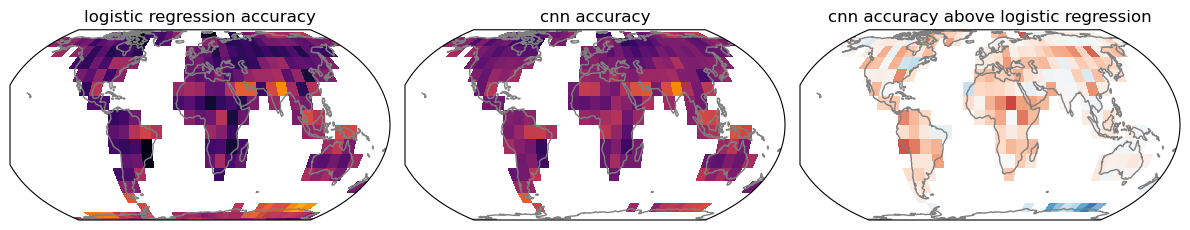

In [62]:
plt.figure(figsize=(12,5))

a1=plt.subplot(1,3,1,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,lr_accuracy_all[:,:,0],vmin=0.5,vmax=0.9,cmap='inferno',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('logistic regression accuracy')

a1=plt.subplot(1,3,2,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,0],vmin=0.5,vmax=0.9,cmap='inferno',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy')

a1=plt.subplot(1,3,3,projection=ccrs.EqualEarth())
a1.pcolormesh(lonvec+5,latvec+5,bestaccs[:,:,0]-lr_accuracy_all[:,:,0],vmin=-0.15,vmax=0.15,cmap='RdBu_r',transform=ccrs.PlateCarree())
a1.coastlines(color='gray')
plt.title('cnn accuracy above logistic regression')

plt.tight_layout()

/var/folders/b4/wvswr5295zj_j2dn8xjmpk91cllg7l/T/ipykernel_45690/4123078310.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


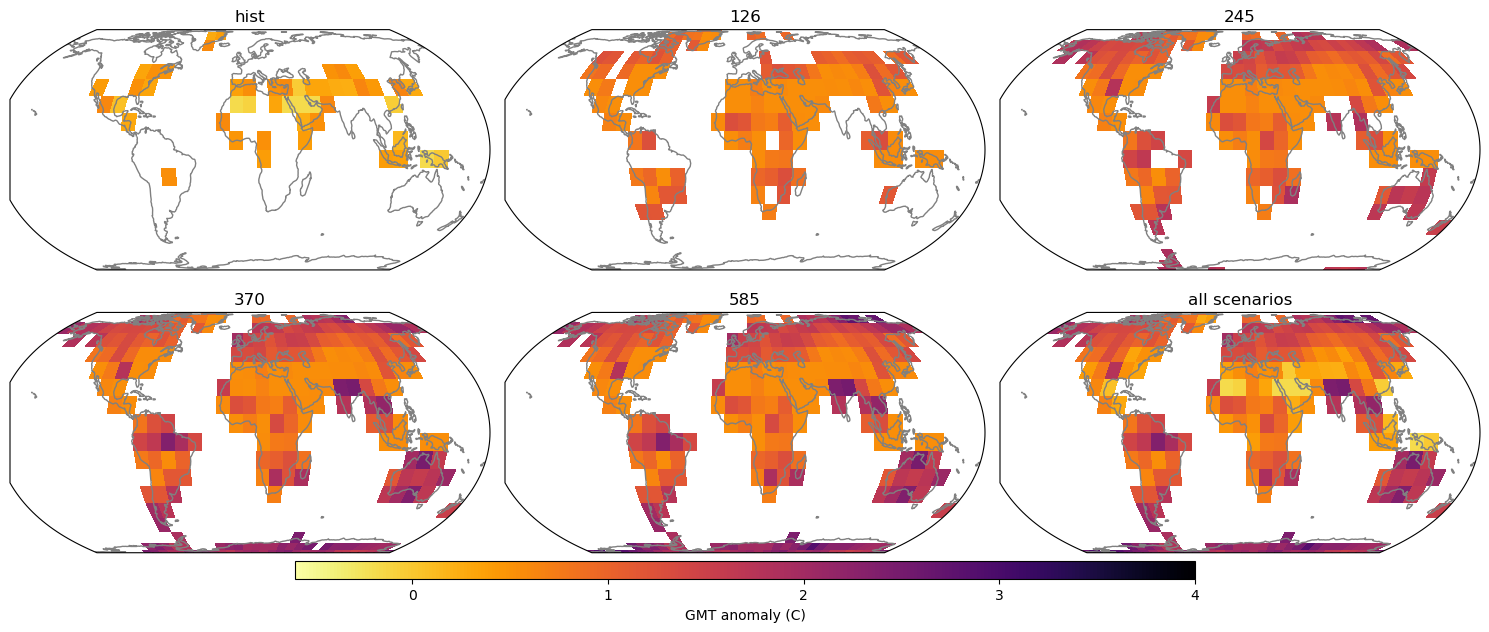

In [ ]:
plt.figure(figsize=(15,6))

for iplot in range(5):

    ax=plt.subplot(2,3,iplot+1,projection=ccrs.EqualEarth())
    ax.pcolormesh(lonvec+5,latvec+5,lr_first_correct[iplot],vmin=-0.6,vmax=4,cmap='inferno_r',transform=ccrs.PlateCarree())
    plt.title(ssplistplot[iplot])
    ax.coastlines(color='gray')

# all_lr_first_correct = np.nanmin(lr_first_correct,axis=0)

# mask = np.isnan(lr_first_correct[-1])
# avgfirstcorrect_lr = np.copy(lr_first_correct)

# avgfirstcorrect_lr[np.isnan(lr_first_correct)] = 0
# avgfirstcorrect_lr[~np.isnan(lr_first_correct)] = 1
# all_first_correct_scenario_lr = np.mean(avgfirstcorrect_lr,axis=0)

# all_first_correct_scenario_lr[mask] = np.nan

ax=plt.subplot(2,3,6,projection=ccrs.EqualEarth())
c1=ax.pcolormesh(lonvec+5,latvec+5,np.nanmin(lr_first_correct,axis=0),vmin=-0.6,vmax=4,cmap='inferno_r',transform=ccrs.PlateCarree())
plt.title('all scenarios')
ax.coastlines(color='gray')

cax1 = plt.axes((0.2,0.02,0.6,0.03))
cbar1 = plt.colorbar(c1,cax1,orientation='horizontal')
cbar1.ax.set_xlabel('GMT anomaly from 1960-1990 (C)')

plt.tight_layout()
plt.show()


baseline for gmt is 20 50
baseline for temp records is 0 20
